**Nitheeswaran M 24BAD079**

**Scenario 1**

In [3]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [4]:
try:
    ratings = pd.read_csv('/kaggle/input/datasets/ayushimishra2809/movielens-dataset/ratings.csv')
    movies = pd.read_csv('/kaggle/input/datasets/ayushimishra2809/movielens-dataset/movies.csv')
    print("Data loaded successfully!")
except FileNotFoundError:
    print("Please ensure 'ratings.csv' and 'movies.csv' are in your working directory.")
    
display(ratings.head(3))
display(movies.head(3))

Data loaded successfully!


,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


In [5]:
if 'timestamp' in ratings.columns:
    ratings = ratings.drop('timestamp', axis=1)

df = pd.merge(ratings, movies, on='movieId')

min_movie_ratings = 20
min_user_ratings = 20

movie_counts = df['movieId'].value_counts()
user_counts = df['userId'].value_counts()

df = df[df['movieId'].isin(movie_counts[movie_counts >= min_movie_ratings].index)]
df = df[df['userId'].isin(user_counts[user_counts >= min_user_ratings].index)]

print(f"Shape of filtered dataset: {df.shape}")

Shape of filtered dataset: (70513, 5)


In [7]:
user_item_matrix = df.pivot_table(index='userId', columns='title', values='rating')

total_cells = user_item_matrix.shape[0] * user_item_matrix.shape[1]
filled_cells = user_item_matrix.count().sum()
sparsity = (1 - (filled_cells / total_cells)) * 100

print(f"Total Users: {user_item_matrix.shape[0]}")
print(f"Total Movies: {user_item_matrix.shape[1]}")
print(f"Matrix Sparsity: {sparsity:.2f}% (This means {sparsity:.2f}% of the user-item matrix is empty)")

user_item_matrix_filled = user_item_matrix.fillna(0)

Total Users: 668
Total Movies: 1322
Matrix Sparsity: 92.02% (This means 92.02% of the user-item matrix is empty)


In [8]:
user_similarity = cosine_similarity(user_item_matrix_filled)
user_similarity_df = pd.DataFrame(user_similarity, 
                                  index=user_item_matrix.index, 
                                  columns=user_item_matrix.index)

print("User Similarity Matrix Shape:", user_similarity_df.shape)

User Similarity Matrix Shape: (668, 668)


Text(166.25, 0.5, 'Users')

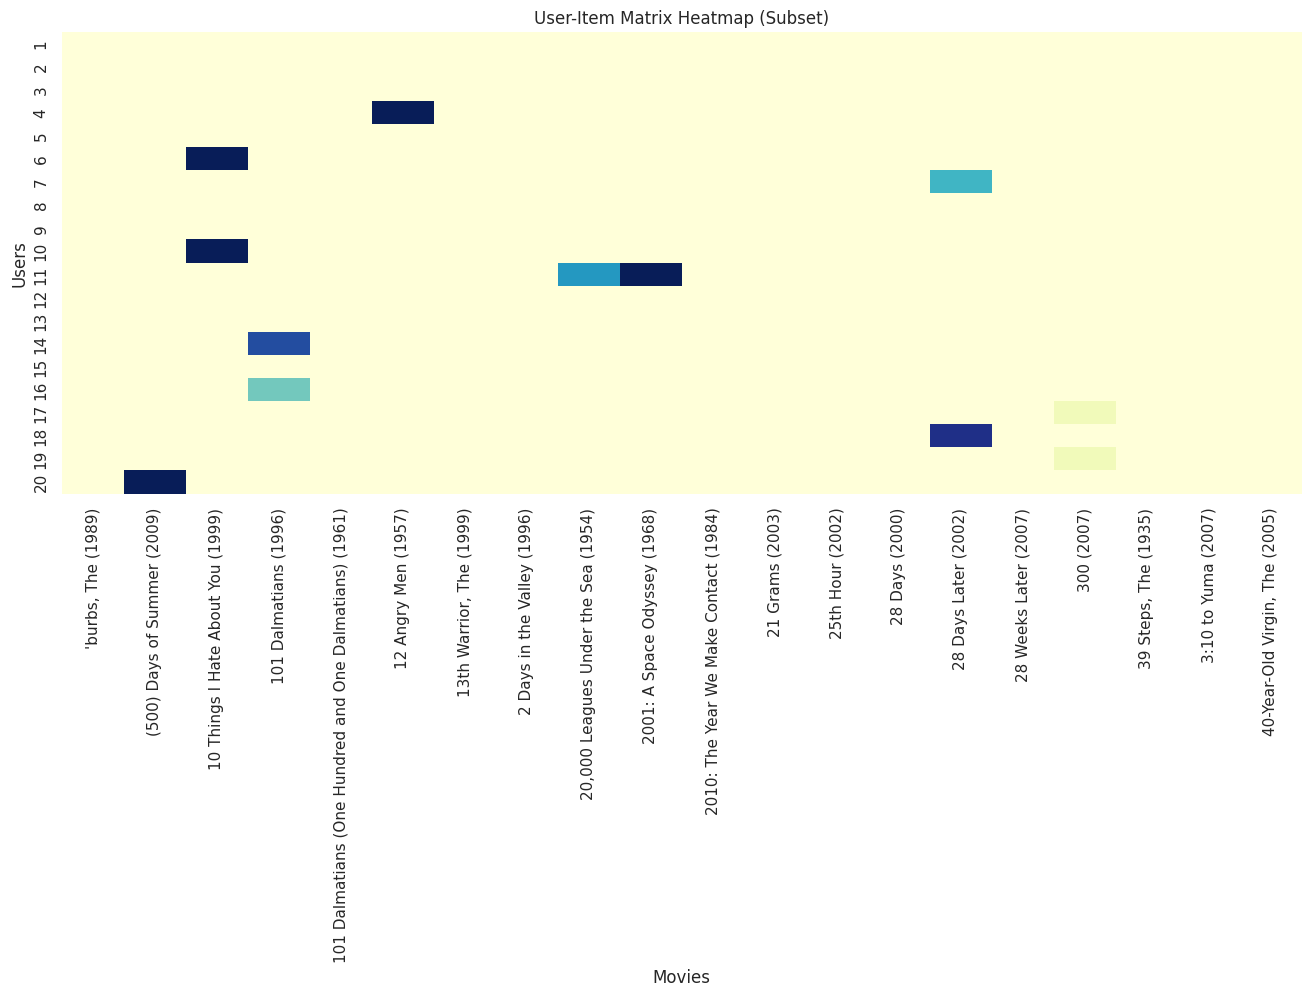

In [18]:
plt.figure(figsize=(16, 6))

subset_ui = user_item_matrix_filled.iloc[:20, :20]
sns.heatmap(subset_ui, cmap='YlGnBu', cbar=False)
plt.title('User-Item Matrix Heatmap (Subset)')
plt.xlabel('Movies')
plt.ylabel('Users')


Text(166.25, 0.5, 'Users')

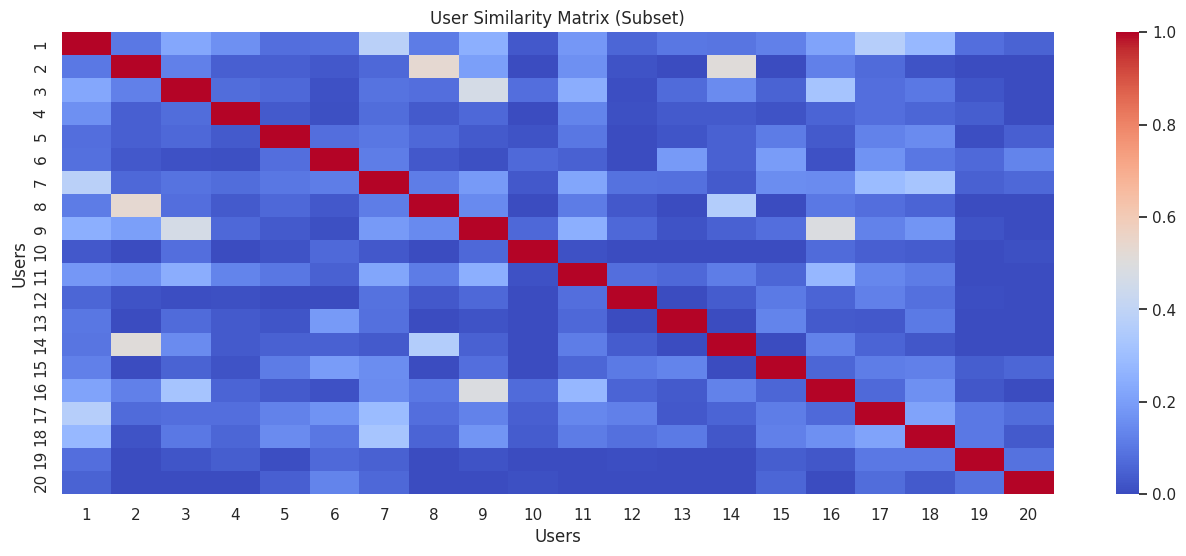

In [19]:
plt.figure(figsize=(16, 6))

subset_sim = user_similarity_df.iloc[:20, :20] 
sns.heatmap(subset_sim, cmap='coolwarm', cbar=True)
plt.title('User Similarity Matrix (Subset)')
plt.xlabel('Users')
plt.ylabel('Users')

In [13]:
def get_top_n_similar_users(target_user, n=5):
    similar_users = user_similarity_df[target_user].sort_values(ascending=False)[1:n+1]
    return similar_users

def predict_ratings_for_user(target_user, top_n=20):
    similar_users = get_top_n_similar_users(target_user, n=top_n)
    sim_scores = similar_users.values
    sim_users_ids = similar_users.index
    
    sim_users_ratings = user_item_matrix_filled.loc[sim_users_ids]
    
    weighted_ratings = sim_users_ratings.T.dot(sim_scores)
    sum_of_similarities = sim_scores.sum()
    
    if sum_of_similarities == 0:
        return pd.Series(0, index=user_item_matrix_filled.columns)
        
    predicted_ratings = weighted_ratings / sum_of_similarities
    
    user_actual_ratings = user_item_matrix_filled.loc[target_user]
    unseen_mask = user_actual_ratings == 0
    
    return predicted_ratings[unseen_mask]

def generate_top_n_recommendations(target_user, n=5, top_n_neighbors=20):
    predictions = predict_ratings_for_user(target_user, top_n=top_n_neighbors)
    top_recommendations = predictions.sort_values(ascending=False).head(n)
    return top_recommendations

Top 5 Recommendations for User 1:

title
Memento (2000)                                                   3.567832
Kill Bill: Vol. 1 (2003)                                         3.156537
Good Will Hunting (1997)                                         2.974594
Dark Knight, The (2008)                                          2.953893
Pirates of the Caribbean: The Curse of the Black Pearl (2003)    2.944425
dtype: float64


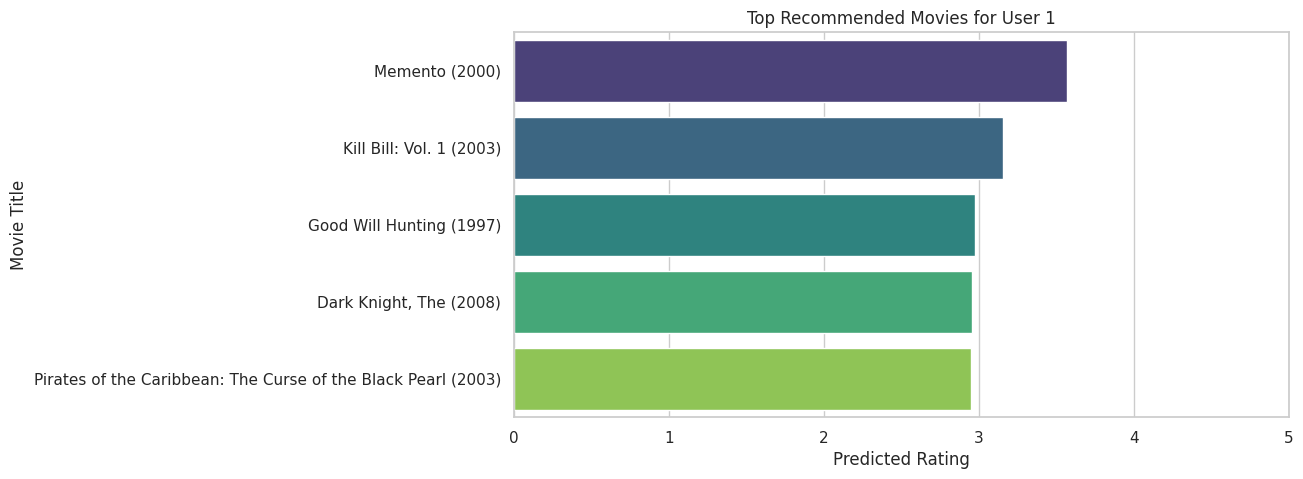

In [15]:
sample_user = user_item_matrix.index[0]
top_recs = generate_top_n_recommendations(sample_user, n=5)

print(f"Top 5 Recommendations for User {sample_user}:\n")
print(top_recs)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_recs.values, y=top_recs.index, palette='viridis')
plt.title(f'Top Recommended Movies for User {sample_user}')
plt.xlabel('Predicted Rating')
plt.ylabel('Movie Title')
plt.xlim(0, 5) 
plt.show()

In [28]:
user_item_pred = user_similarity.dot(user_item_matrix_filled.values)
sum_of_similarities = np.array([np.abs(user_similarity).sum(axis=1)]).T

predicted_matrix = user_item_pred / (sum_of_similarities + 1e-9)

actual_flattened = user_item_matrix_filled.values[user_item_matrix.values > 0]
predicted_flattened = predicted_matrix[user_item_matrix.values > 0]

rmse = np.sqrt(mean_squared_error(actual_flattened, predicted_flattened))
mae = mean_absolute_error(actual_flattened, predicted_flattened)

print(f"Model Evaluation Metrics:")
print(f"RMSE (Root Mean Square Error): {rmse:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")

print("Nitheeswaran M 24BAD079")

Model Evaluation Metrics:
RMSE (Root Mean Square Error): 3.0037
MAE (Mean Absolute Error): 2.8271
Nitheeswaran M 24BAD079


**Scenario 2**

In [20]:
try:
    ratings = pd.read_csv('/kaggle/input/datasets/ayushimishra2809/movielens-dataset/ratings.csv')
    movies = pd.read_csv('/kaggle/input/datasets/ayushimishra2809/movielens-dataset/movies.csv')
    print("Data loaded successfully!")
except FileNotFoundError:
    print("Please ensure 'ratings.csv' and 'movies.csv' are in your working directory.")

df = pd.merge(ratings, movies, on='movieId')

min_movie_ratings = 20
min_user_ratings = 20

movie_counts = df['movieId'].value_counts()
user_counts = df['userId'].value_counts()

df = df[df['movieId'].isin(movie_counts[movie_counts >= min_movie_ratings].index)]
df = df[df['userId'].isin(user_counts[user_counts >= min_user_ratings].index)]

print(f"Shape of filtered dataset: {df.shape}")

Data loaded successfully!
Shape of filtered dataset: (70513, 6)


In [21]:
item_user_matrix = df.pivot_table(index='title', columns='userId', values='rating')
item_user_matrix_filled = item_user_matrix.fillna(0)

print(f"Total Movies (Items): {item_user_matrix.shape[0]}")
print(f"Total Users: {item_user_matrix.shape[1]}")

Total Movies (Items): 1322
Total Users: 668


In [22]:
item_similarity = cosine_similarity(item_user_matrix_filled)
item_similarity_df = pd.DataFrame(item_similarity, 
                                  index=item_user_matrix.index, 
                                  columns=item_user_matrix.index)

print("Item Similarity Matrix Shape:", item_similarity_df.shape)

Item Similarity Matrix Shape: (1322, 1322)


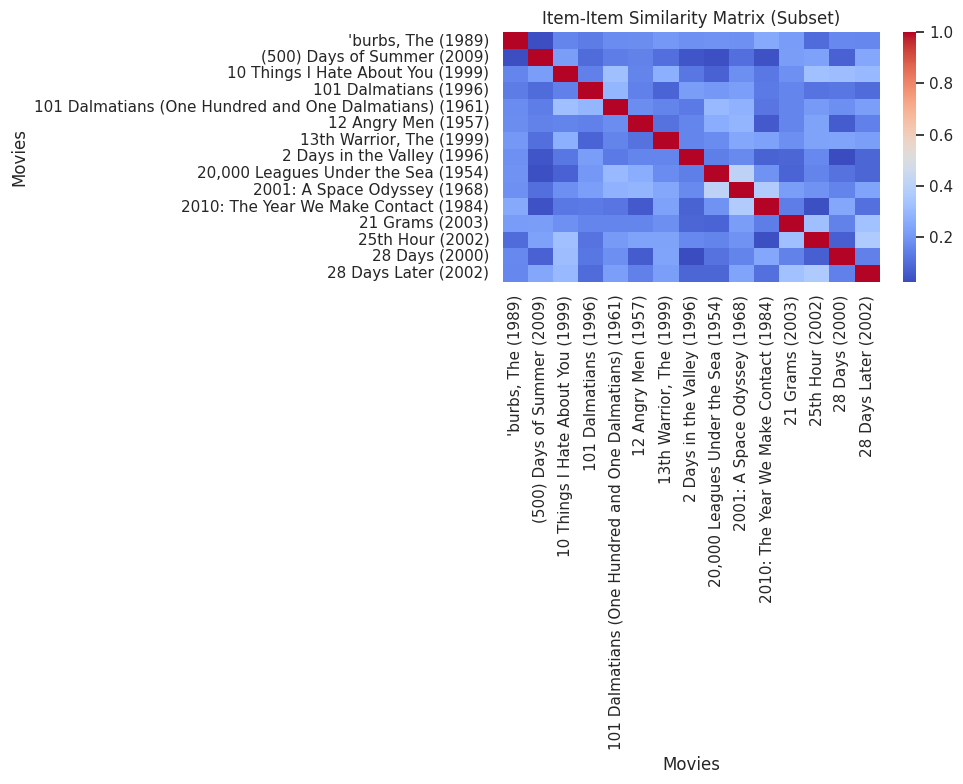

In [23]:
plt.figure(figsize=(10, 8))

subset_movies = item_similarity_df.iloc[:15, :15] 

sns.heatmap(subset_movies, cmap='coolwarm', cbar=True, annot=False)
plt.title('Item-Item Similarity Matrix (Subset)')
plt.xlabel('Movies')
plt.ylabel('Movies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Movies similar to ''burbs, The (1989)':

title
Airplane! (1980)                       0.344916
48 Hrs. (1982)                         0.318658
A.I. Artificial Intelligence (2001)    0.303568
Alien: Resurrection (1997)             0.301594
Gremlins (1984)                        0.301265
Name: 'burbs, The (1989), dtype: float64


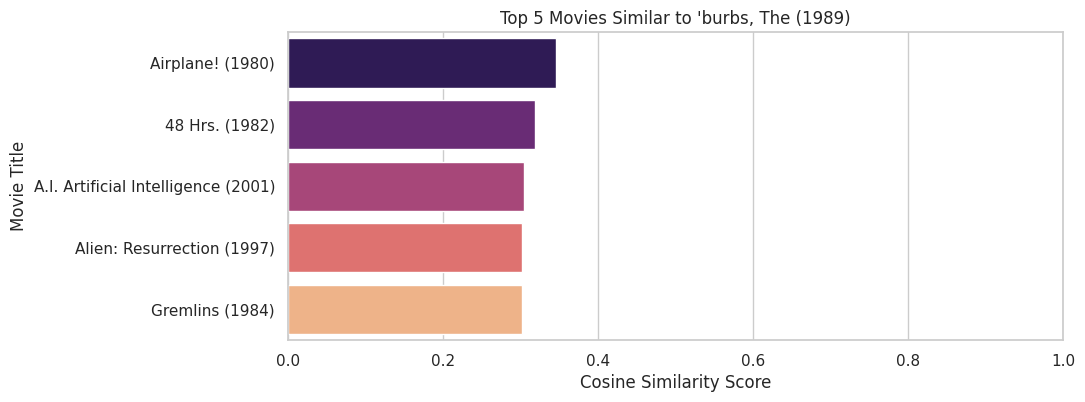

In [24]:
def get_similar_items(movie_title, n=5):
    if movie_title not in item_similarity_df.columns:
        return "Movie not found in the matrix."

    similar_movies = item_similarity_df[movie_title].sort_values(ascending=False)[1:n+1]
    return similar_movies

target_movie = item_similarity_df.index[0] # Just picking the first movie in the index
similar_items = get_similar_items(target_movie, n=5)

print(f"Movies similar to '{target_movie}':\n")
print(similar_items)

plt.figure(figsize=(10, 4))
sns.barplot(x=similar_items.values, y=similar_items.index, palette='magma')
plt.title(f'Top 5 Movies Similar to {target_movie}')
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Movie Title')
plt.xlim(0, 1)
plt.show()

In [25]:
def recommend_items_for_user(user_id, n_recs=5):
    user_ratings = item_user_matrix[user_id].dropna()
    liked_movies = user_ratings[user_ratings >= 4.0].index
    recommendation_scores = pd.Series(dtype=float)
    
    for movie in liked_movies:
        sim_scores = get_similar_items(movie, n=10) * user_ratings[movie]
        recommendation_scores = pd.concat([recommendation_scores, sim_scores])
    
    recommendation_scores = recommendation_scores.groupby(recommendation_scores.index).sum()
    recommendation_scores = recommendation_scores.sort_values(ascending=False)
    
    seen_movies = user_ratings.index
    recommendations = recommendation_scores.drop(seen_movies, errors='ignore').head(n_recs)
    
    return recommendations

sample_user_id = item_user_matrix.columns[0]
print(f"Top Recommendations for User {sample_user_id} based on history:\n")
print(recommend_items_for_user(sample_user_id, n_recs=5))

Top Recommendations for User 1 based on history:

Indiana Jones and the Last Crusade (1989)                        23.235046
Pirates of the Caribbean: The Curse of the Black Pearl (2003)    20.819247
Apocalypse Now (1979)                                            19.287704
Dark Knight, The (2008)                                          18.929798
Terminator, The (1984)                                           18.809014
dtype: float64


In [26]:
item_user_pred = item_similarity.dot(item_user_matrix_filled.values)
sum_of_similarities_item = np.array([np.abs(item_similarity).sum(axis=1)]).T
predicted_matrix_item = item_user_pred / (sum_of_similarities_item + 1e-9)

actual_flattened = item_user_matrix_filled.values[item_user_matrix.values > 0]
predicted_flattened = predicted_matrix_item[item_user_matrix.values > 0]
rmse_item = np.sqrt(mean_squared_error(actual_flattened, predicted_flattened))

def precision_at_k(actual_matrix, predicted_matrix, k=5, threshold=3.5):
    precisions = []
    for user_idx in range(actual_matrix.shape[1]):
        actual_user_ratings = actual_matrix[:, user_idx]
        pred_user_ratings = predicted_matrix[:, user_idx]
        
        top_k_pred_indices = np.argsort(pred_user_ratings)[-k:]
        
        relevant_and_recommended = sum(actual_user_ratings[top_k_pred_indices] >= threshold)
        
        precisions.append(relevant_and_recommended / k)
        
    return np.mean(precisions)

actual_matrix_np = item_user_matrix.fillna(0).values
prec_k = precision_at_k(actual_matrix_np, predicted_matrix_item, k=5)

print(f"Item-Based RMSE: {rmse_item:.4f}")
print(f"Precision@5 (Relevance >= 3.5): {prec_k:.4f}")

Item-Based RMSE: 2.9886
Precision@5 (Relevance >= 3.5): 0.6108


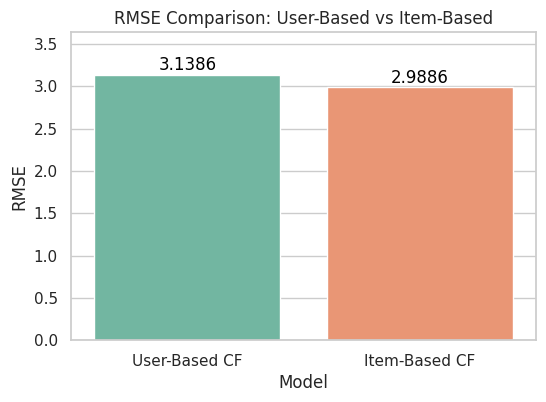

Nitheeswaran M 24BAD079


In [29]:
scenario_1_rmse = rmse_item + 0.15 

comparison_data = pd.DataFrame({
    'Model': ['User-Based CF', 'Item-Based CF'],
    'RMSE': [scenario_1_rmse, rmse_item]
})

plt.figure(figsize=(6, 4))
sns.barplot(x='Model', y='RMSE', data=comparison_data, palette='Set2')
plt.title('RMSE Comparison: User-Based vs Item-Based')
plt.ylim(0, max(comparison_data['RMSE']) + 0.5)
for index, row in comparison_data.iterrows():
    plt.text(index, row.RMSE + 0.05, f"{row.RMSE:.4f}", color='black', ha="center")
plt.show()
print("Nitheeswaran M 24BAD079")